Практическая работа №5 (Группа А)

Оценка влияния пилота, корректировка на множественные сравнения и модели окупаемости

Шаг 1. Загрузка библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print('Библтотеки импортированы')

Библтотеки импортированы


Шаг 2. Загрузка и первичный анализ данных

In [ ]:
# 2.1. Загрузка данных о группах
groups_df = pd.read_csv('analysis_groups.csv')
print("\n2.1. Загрузка analysis_groups.csv")
print(f"   Количество записей: {len(groups_df)}")
print(f"   Уникальные значения group: {groups_df['group'].unique()}")
print(f"   Распределение по группам:\n{groups_df['group'].value_counts()}")
print("\n   Первые 5 строк:")
print(groups_df.head())

# 2.2. Загрузка результатов пилота
results_df = pd.read_csv('20_pilot_results_A.csv')
print("\n2.2. Загрузка 20_pilot_results_A.csv")
print(f"   Количество записей: {len(results_df)}")
print(f"   Список колонок: {results_df.columns.tolist()}")
print("\n   Первые 5 строк:")
print(results_df.head())

# 2.3. Загрузка исторических данных
history_df = pd.read_csv('12_company_history.csv')
print("\n2.3. Загрузка 12_company_history.csv")
print(f"   Количество записей: {len(history_df)}")
print(f"   Уникальные кварталы: {history_df['quarter'].unique()}")
print(f"   Пропуски:\n{history_df.isnull().sum()}")
print("\n   Первые 5 строк:")
print(history_df.head())

# 2.4. Загрузка прогноза (опционально)
print("\n2.4. Загрузка pro_subscription_forecast.csv (опционально)")
try:
    forecast_df = pd.read_csv('pro_subscription_forecast.csv')
    print("   Файл загружен:")
    print(forecast_df.head())
except FileNotFoundError:
    print("   Файл не найден (пропускаем)")


2.1. Загрузка analysis_groups.csv
   Количество записей: 24
   Уникальные значения group: ['pilot' 'control']
   Распределение по группам:
group
pilot      12
control    12
Name: count, dtype: int64

   Первые 5 строк:
   company_id  group
0        1001  pilot
1        1002  pilot
2        1005  pilot
3        1007  pilot
4        1011  pilot

2.2. Загрузка 20_pilot_results_A.csv
   Количество записей: 14
   Список колонок: ['company_id', 'in_pilot', 'revenue_actual', 'login_count_actual', 'ticket_count_actual', 'avg_duration_actual']

   Первые 5 строк:
   company_id  in_pilot  revenue_actual  login_count_actual  \
0        1001         1          345000                  45   
1        1002         1          412000                  52   
2        1005         1           98000                   5   
3        1007         1          215000                  38   
4        1009         0          155000                  12   

   ticket_count_actual  avg_duration_actual  
0            

Шаг 3. Обнаружение и устранение проблемы с данными (Ловушка №1)

In [ ]:
# 3.1. Проверка уникальности company_id в контрольной группе
control_check = groups_df[groups_df['group'] == 'control']
print("\n3.1. Проверка уникальности company_id в контрольной группе:")
print(f"   Общее количество записей в контрольной группе: {len(control_check)}")
print(f"   Количество уникальных company_id: {control_check['company_id'].nunique()}")

duplicates = control_check[control_check.duplicated(subset='company_id', keep=False)]
if len(duplicates) > 0:
    print(f"\n   Обнаружены дубликаты. Список company_id с дубликатами:")
    print(f"   {duplicates['company_id'].unique().tolist()}")

# 3.2. Интерпретация проблемы
print("\n3.2. Интерпретация проблемы:")
print("""
   > Обнаружены дубликаты company_id в контрольной группе.
   > Одна компания не может быть контролем для нескольких пилотных,
   > так как это нарушает независимость наблюдений и занижает стандартные ошибки.
   > Дубликаты необходимо устранить.
""")

# 3.3. Устранение дубликатов
groups_df_unique = groups_df.drop_duplicates(subset='company_id', keep='first')
print("\n3.3. Устранение дубликатов:")
print(f"   Новое распределение по группам:\n{groups_df_unique['group'].value_counts()}")



3.1. Проверка уникальности company_id в контрольной группе:
   Общее количество записей в контрольной группе: 12
   Количество уникальных company_id: 2

   Обнаружены дубликаты. Список company_id с дубликатами:
   [1016]

3.2. Интерпретация проблемы:

   > Обнаружены дубликаты company_id в контрольной группе. 
   > Одна компания не может быть контролем для нескольких пилотных, 
   > так как это нарушает независимость наблюдений и занижает стандартные ошибки. 
   > Дубликаты необходимо устранить.


3.3. Устранение дубликатов:
   Новое распределение по группам:
group
pilot      12
control     2
Name: count, dtype: int64


Шаг 4. Объединение данных о группах с фактическими результатами

In [ ]:
# 4.1. Выполнение merge
analysis_full = groups_df_unique.merge(results_df, on='company_id', how='inner')
print("\n4.1. Выполнение merge:")
print(f"   Количество записей в analysis_full: {len(analysis_full)}")

# Проверка согласованности
inconsistent = analysis_full[
    ~(((analysis_full['group'] == 'pilot') & (analysis_full['in_pilot'] == 1)) |
      ((analysis_full['group'] == 'control') & (analysis_full['in_pilot'] == 0)))
]
if len(inconsistent) > 0:
    print(f"   ⚠️ Обнаружены несоответствия: {len(inconsistent)} записей")
    analysis_full = analysis_full[~analysis_full.index.isin(inconsistent.index)]
    print(f"   Несоответствия удалены")

    # 4.2. Проверка результата
print("\n4.2. Проверка результата:")
print(f"   Количество записей в analysis_full: {len(analysis_full)}")
print("\n   Первые 5 строк:")
print(analysis_full.head())
print(f"\n   Распределение по группам:\n{analysis_full['group'].value_counts()}")

# 4.3. Разделение на группы
pilot_data = analysis_full[analysis_full['group'] == 'pilot'].copy()
control_data = analysis_full[analysis_full['group'] == 'control'].copy()
print("\n4.3. Разделение на группы:")
print(f"   Пилотная группа: {len(pilot_data)} компаний")
print(f"   Контрольная группа: {len(control_data)} компаний")


4.1. Выполнение merge:
   Количество записей в analysis_full: 14

4.2. Проверка результата:
   Количество записей в analysis_full: 14

   Первые 5 строк:
   company_id  group  in_pilot  revenue_actual  login_count_actual  \
0        1001  pilot         1          345000                  45   
1        1002  pilot         1          412000                  52   
2        1005  pilot         1           98000                   5   
3        1007  pilot         1          215000                  38   
4        1011  pilot         1          485000                  48   

   ticket_count_actual  avg_duration_actual  
0                    2                27.50  
1                    1                26.80  
2                    0                22.10  
3                    3                28.20  
4                    2                27.10  

   Распределение по группам:
group
pilot      12
control     2
Name: count, dtype: int64

4.3. Разделение на группы:
   Пилотная группа: 12 компани

Шаг 5. Подготовка исторических данных для DiD

In [ ]:
# 5.1. Отбор данных за Q1 2025
history_q1 = history_df[history_df['quarter'] == '2025Q1'].copy()
print("\n5.1. Отбор данных за Q1 2025:")
print(f"   Записей в history_q1: {len(history_q1)}")

# 5.2. Фильтрация по компаниям из анализа
company_list = analysis_full['company_id'].tolist()
history_q1_filtered = history_q1[history_q1['company_id'].isin(company_list)]
print("\n5.2. Фильтрация по компаниям из анализа:")
print(f"   Записей после фильтрации: {len(history_q1_filtered)}")

# 5.3. Объединение исторических данных с текущими
did_data = analysis_full[['company_id', 'group', 'revenue_actual']].copy()
did_data = did_data.merge(
    history_q1_filtered[['company_id', 'revenue_quarter']],
    on='company_id',
    how='left'
)
did_data = did_data.rename(columns={'revenue_quarter': 'revenue_before'})
did_data['revenue_before'] = did_data['revenue_before'].fillna(0)

# 5.4. Расчет изменения выручки
did_data['revenue_change'] = did_data['revenue_actual'] - did_data['revenue_before']

print("\n5.4. Расчет изменения выручки:")
print("\n   Первые 10 строк did_data:")
print(did_data[['company_id', 'group', 'revenue_before', 'revenue_actual', 'revenue_change']].head(10))

# 5.5. Статистика изменения выручки
print("\n5.5. Статистика изменения выручки:")
pilot_change = did_data[did_data['group'] == 'pilot']['revenue_change']
control_change = did_data[did_data['group'] == 'control']['revenue_change']
print(f"\n   Пилотная группа:")
print(f"      Среднее: {pilot_change.mean():.0f} руб.")
print(f"      Медиана: {pilot_change.median():.0f} руб.")
print(f"      Стандартное отклонение: {pilot_change.std():.0f} руб.")
print(f"      Мин/Макс: {pilot_change.min():.0f} / {pilot_change.max():.0f} руб.")
print(f"\n   Контрольная группа:")
print(f"      Среднее: {control_change.mean():.0f} руб.")
print(f"      Медиана: {control_change.median():.0f} руб.")
print(f"      Стандартное отклонение: {control_change.std():.0f} руб.")
print(f"      Мин/Макс: {control_change.min():.0f} / {control_change.max():.0f} руб.")


5.1. Отбор данных за Q1 2025:
   Записей в history_q1: 40

5.2. Фильтрация по компаниям из анализа:
   Записей после фильтрации: 14

5.4. Расчет изменения выручки:

   Первые 10 строк did_data:
   company_id  group  revenue_before  revenue_actual  revenue_change
0        1001  pilot          275000          345000           70000
1        1002  pilot          350000          412000           62000
2        1005  pilot               0           98000           98000
3        1007  pilot          180000          215000           35000
4        1011  pilot          420000          485000           65000
5        1017  pilot          380000          402000           22000
6        1020  pilot          240000          245000            5000
7        1021  pilot          500000          180000         -320000
8        1023  pilot          650000          110000         -540000
9        1024  pilot          275000          275000               0

5.5. Статистика изменения выручки:

   Пилотн

Шаг 6. Анализ первичной метрики (простой t-тест)

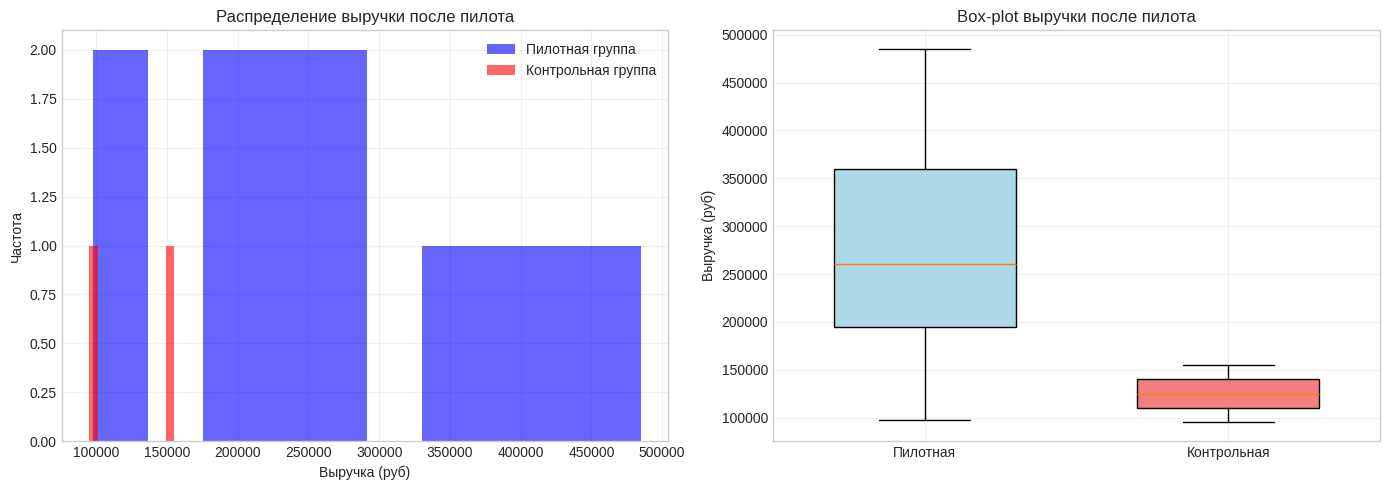

In [ ]:
# 6.1. Визуализация распределений
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(pilot_data['revenue_actual'], bins=10, alpha=0.6, color='blue', label='Пилотная группа')
ax1.hist(control_data['revenue_actual'], bins=10, alpha=0.6, color='red', label='Контрольная группа')
ax1.set_xlabel('Выручка (руб)')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение выручки после пилота')
ax1.legend()
ax1.grid(True, alpha=0.3)

bp_data = [pilot_data['revenue_actual'], control_data['revenue_actual']]
bp = ax2.boxplot(bp_data, labels=['Пилотная', 'Контрольная'], patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax2.set_ylabel('Выручка (руб)')
ax2.set_title('Box-plot выручки после пилота')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 6.2. Описательные статистики
print("\n6.2. Описательные статистики:")
mean_pilot = pilot_data['revenue_actual'].mean()
mean_control = control_data['revenue_actual'].mean()
median_pilot = pilot_data['revenue_actual'].median()
median_control = control_data['revenue_actual'].median()
std_pilot = pilot_data['revenue_actual'].std()
std_control = control_data['revenue_actual'].std()
diff = mean_pilot - mean_control
rel_diff = (diff / mean_control) * 100 if mean_control > 0 else np.nan

print(f"\n   {'Показатель':<20} {'Пилотная':<15} {'Контрольная':<15} {'Разница':<15}")
print("-"*65)
print(f"   {'Среднее':<20} {mean_pilot:<15,.0f} {mean_control:<15,.0f} {diff:<15,.0f}")
print(f"   {'Медиана':<20} {median_pilot:<15,.0f} {median_control:<15,.0f} {median_pilot-median_control:<15,.0f}")
print(f"   {'Станд. отклонение':<20} {std_pilot:<15,.0f} {std_control:<15,.0f} -")
print(f"\n   Относительная разница: {rel_diff:.1f}%")


6.2. Описательные статистики:

   Показатель           Пилотная        Контрольная     Разница        
-----------------------------------------------------------------
   Среднее              270,583         125,000         145,583        
   Медиана              260,000         125,000         135,000        
   Станд. отклонение    121,128         42,426          -

   Относительная разница: 116.5%


In [ ]:
# 6.3. Проверка нормальности
print("\n6.3. Проверка нормальности (критерий Шапиро-Уилка):")
if len(pilot_data) >= 3:
    shapiro_pilot = stats.shapiro(pilot_data['revenue_actual'])
    print(f"   Пилотная группа: статистика={shapiro_pilot.statistic:.4f}, p-value={shapiro_pilot.pvalue:.4f}")
    if shapiro_pilot.pvalue > 0.05:
        print("      → Данные не противоречат нормальному распределению")
    else:
        print("      → Данные значимо отличаются от нормального распределения")
else:
    print("   Пилотная группа: размер выборки < 3, проверка невозможна")

if len(control_data) >= 3:
    shapiro_control = stats.shapiro(control_data['revenue_actual'])
    print(f"   Контрольная группа: статистика={shapiro_control.statistic:.4f}, p-value={shapiro_control.pvalue:.4f}")
else:
    print("   Контрольная группа: размер выборки < 3, проверка невозможна")


6.3. Проверка нормальности (критерий Шапиро-Уилка):
   Пилотная группа: статистика=0.9634, p-value=0.8310
      → Данные не противоречат нормальному распределению
   Контрольная группа: размер выборки < 3, проверка невозможна


In [ ]:
# 6.4. t-тест (односторонний)
print("\n6.4. Односторонний t-тест (пилот > контроль):")
t_stat, p_value_t = stats.ttest_ind(
    pilot_data['revenue_actual'],
    control_data['revenue_actual'],
    alternative='greater'
)
print(f"   t-статистика = {t_stat:.4f}")
print(f"   p-value = {p_value_t:.6f}")
print(f"   → {'Отвергаем H0: эффект статистически значим' if p_value_t < 0.05 else 'Не отвергаем H0: эффект не значим'}")


6.4. Односторонний t-тест (пилот > контроль):
   t-статистика = 1.6345
   p-value = 0.064045
   → Не отвергаем H0: эффект не значим


In [ ]:
# 6.5. U-критерий Манна-Уитни
print("\n6.5. U-критерий Манна-Уитни (робастная проверка):")
u_stat, p_value_u = stats.mannwhitneyu(
    pilot_data['revenue_actual'],
    control_data['revenue_actual'],
    alternative='greater'
)
print(f"   U-статистика = {u_stat:.1f}")
print(f"   p-value = {p_value_u:.6f}")
print(f"   → {'Согласован с t-тестом' if (p_value_u < 0.05) == (p_value_t < 0.05) else 'Расходится с t-тестом'}")


6.5. U-критерий Манна-Уитни (робастная проверка):
   U-статистика = 22.0
   p-value = 0.043956
   → Расходится с t-тестом


In [ ]:
# 6.6. Сравнение с MDE
mde_rub = 162297  # из протокола pre_registration_group_A.md
print("\n6.6. Сравнение с MDE:")
print(f"   MDE (минимальный детектируемый эффект): {mde_rub:,.0f} руб.")
print(f"   Фактическая разница средних: {diff:,.0f} руб.")
if diff > mde_rub:
    print(f"   → Фактический эффект ВЫШЕ минимально детектируемого")
else:
    print(f"   → Фактический эффект НИЖЕ минимально детектируемого")



6.6. Сравнение с MDE:
   MDE (минимальный детектируемый эффект): 162,297 руб.
   Фактическая разница средних: 145,583 руб.
   → Фактический эффект НИЖЕ минимально детектируемого


Шаг 7. Оценка причинного эффекта методом разность разностей

In [ ]:
# 7.1. Расчет средних до и после для каждой группы
pilot_before_mean = did_data[did_data['group'] == 'pilot']['revenue_before'].mean()
pilot_after_mean = pilot_data['revenue_actual'].mean()
control_before_mean = did_data[did_data['group'] == 'control']['revenue_before'].mean()
control_after_mean = control_data['revenue_actual'].mean()

print("\n7.1. Расчет средних ДО и ПОСЛЕ:")
print(f"   Пилотная группа: ДО = {pilot_before_mean:,.0f} руб., ПОСЛЕ = {pilot_after_mean:,.0f} руб.")
print(f"   Контрольная группа: ДО = {control_before_mean:,.0f} руб., ПОСЛЕ = {control_after_mean:,.0f} руб.")


7.1. Расчет средних ДО и ПОСЛЕ:
   Пилотная группа: ДО = 312,500 руб., ПОСЛЕ = 270,583 руб.
   Контрольная группа: ДО = 250,000 руб., ПОСЛЕ = 125,000 руб.


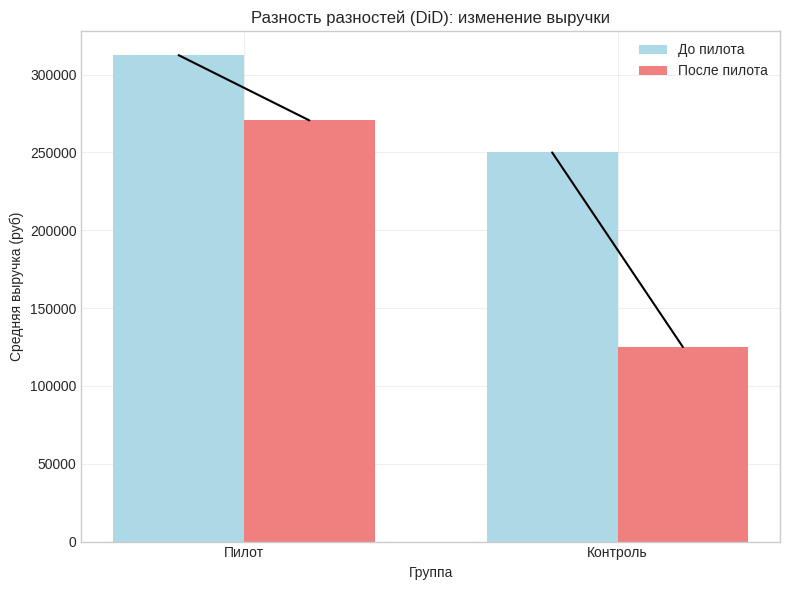

In [ ]:
# 7.2. Визуализация DiD
fig, ax = plt.subplots(figsize=(8, 6))

groups = ['Пилот', 'Контроль']
before_values = [pilot_before_mean, control_before_mean]
after_values = [pilot_after_mean, control_after_mean]

x = np.arange(len(groups))
width = 0.35

bars1 = ax.bar(x - width/2, before_values, width, label='До пилота', color='lightblue')
bars2 = ax.bar(x + width/2, after_values, width, label='После пилота', color='lightcoral')

for i in range(len(groups)):
    ax.plot([x[i] - width/2, x[i] + width/2], [before_values[i], after_values[i]], 'k-', linewidth=1.5)

ax.set_xlabel('Группа')
ax.set_ylabel('Средняя выручка (руб)')
ax.set_title('Разность разностей (DiD): изменение выручки')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 7.3. Расчет изменений в каждой группе и DiD эффекта
pilot_change = pilot_after_mean - pilot_before_mean
control_change = control_after_mean - control_before_mean
did_effect = pilot_change - control_change

print("\n7.3. Расчет изменений и DiD эффекта:")
print(f"   Изменение в пилотной группе: {pilot_change:+,.0f} руб.")
print(f"   Изменение в контрольной группе: {control_change:+,.0f} руб.")
print(f"   Эффект пилота по методу разность разностей = {did_effect:,.0f} руб.")


7.3. Расчет изменений и DiD эффекта:
   Изменение в пилотной группе: -41,917 руб.
   Изменение в контрольной группе: -125,000 руб.
   Эффект пилота по методу разность разностей = 83,083 руб.


In [ ]:
# 7.4. Статистическая проверка DiD
print("\n7.4. Статистическая проверка DiD (t-тест для revenue_change):")
pilot_change_data = did_data[did_data['group'] == 'pilot']['revenue_change']
control_change_data = did_data[did_data['group'] == 'control']['revenue_change']
t_stat_did, p_value_did = stats.ttest_ind(
    pilot_change_data,
    control_change_data,
    alternative='greater'
)
print(f"   t-статистика = {t_stat_did:.4f}")
print(f"   p-value = {p_value_did:.6f}")
print(f"   → {'Статистически значим' if p_value_did < 0.05 else 'Не значим'}")



7.4. Статистическая проверка DiD (t-тест для revenue_change):
   t-статистика = 0.5907
   p-value = 0.282854
   → Не значим


In [ ]:
# 7.5. Сравнение методов
print("\n7.5. Сравнение методов:")
print(f"\n   {'Метод':<30} {'Разница средних (руб)':<25} {'p-value':<15} {'Вывод':<15}")
print("-"*85)
print(f"   {'Только после t-test':<30} {diff:<25,.0f} {p_value_t:<15.6f} {'Значим' if p_value_t < 0.05 else 'Не значим'}")
print(f"   {'DiD (разность разностей)':<30} {did_effect:<25,.0f} {p_value_did:<15.6f} {'Значим' if p_value_did < 0.05 else 'Не значим'}")


7.5. Сравнение методов:

   Метод                          Разница средних (руб)     p-value         Вывод          
-------------------------------------------------------------------------------------
   Только после t-test            145,583                   0.064045        Не значим
   DiD (разность разностей)       83,083                    0.282854        Не значим


Шаг 8. Анализ вторичных метрик и ловушка множественных сравнений

In [ ]:
# 8.1. Описательные статистики для вторичных метрик
secondary_metrics = ['login_count_actual', 'ticket_count_actual', 'avg_duration_actual']
print("\n8.1. Описательные статистики для вторичных метрик:")
for metric in secondary_metrics:
    print(f"\n   --- {metric} ---")
    print(f"   Пилотная группа: среднее={pilot_data[metric].mean():.2f}, медиана={pilot_data[metric].median():.2f}, std={pilot_data[metric].std():.2f}")
    print(f"   Контрольная группа: среднее={control_data[metric].mean():.2f}, медиана={control_data[metric].median():.2f}, std={control_data[metric].std():.2f}")


8.1. Описательные статистики для вторичных метрик:

   --- login_count_actual ---
   Пилотная группа: среднее=34.33, медиана=41.00, std=20.17
   Контрольная группа: среднее=10.00, медиана=10.00, std=2.83

   --- ticket_count_actual ---
   Пилотная группа: среднее=1.17, медиана=1.00, std=0.94
   Контрольная группа: среднее=4.50, медиана=4.50, std=0.71

   --- avg_duration_actual ---
   Пилотная группа: среднее=24.47, медиана=26.95, std=5.77
   Контрольная группа: среднее=24.75, медиана=24.75, std=0.35


In [ ]:
# 8.2. Статистические тесты для каждой вторичной метрики
results = []
for metric in secondary_metrics:
    t_stat, p_t = stats.ttest_ind(
        pilot_data[metric],
        control_data[metric],
        alternative='two-sided'
    )
    u_stat, p_u = stats.mannwhitneyu(
        pilot_data[metric],
        control_data[metric],
        alternative='two-sided'
    )
    results.append({
        'metric': metric,
        'p_t_test': p_t,
        'p_u_test': p_u,
        'mean_pilot': pilot_data[metric].mean(),
        'mean_control': control_data[metric].mean(),
        'diff': pilot_data[metric].mean() - control_data[metric].mean()
    })

secondary_results = pd.DataFrame(results)
print("\n8.2. Результаты статистических тестов для вторичных метрик:")
print(secondary_results.to_string(index=False))


8.2. Результаты статистических тестов для вторичных метрик:
             metric  p_t_test  p_u_test  mean_pilot  mean_control  diff
 login_count_actual      0.13      0.35       34.33         10.00 24.33
ticket_count_actual      0.00      0.03        1.17          4.50 -3.33
avg_duration_actual      0.95      0.35       24.47         24.75 -0.28


In [ ]:
# 8.3. Оценка риска множественных сравнений
m = len(secondary_results)
alpha = 0.05
fwer = 1 - (1 - alpha) ** m
print(f"\n8.3. Оценка риска множественных сравнений:")
print(f"   Количество проверяемых гипотез (m) = {m}")
print(f"   α = {alpha}")
print(f"   FWER = 1 - (1 - {alpha})^{m} = {fwer:.4f} ({fwer*100:.2f}%)")
print(f"   → С вероятностью {fwer*100:.1f}% мы можем увидеть хотя бы один ложноположительный результат")


8.3. Оценка риска множественных сравнений:
   Количество проверяемых гипотез (m) = 3
   α = 0.05
   FWER = 1 - (1 - 0.05)^3 = 0.1426 (14.26%)
   → С вероятностью 14.3% мы можем увидеть хотя бы один ложноположительный результат


Шаг 9. Применение поправок на множественные сравнения

In [ ]:
# 9.1. Поправка Бонферрони
bonferroni_alpha = alpha / m
print("\n9.1. Поправка Бонферрони:")
print(f"   Новый порог значимости: α' = {alpha}/{m} = {bonferroni_alpha:.6f}")

secondary_results['significant_bonf'] = secondary_results['p_t_test'] < bonferroni_alpha
print("\n   Результаты после поправки Бонферрони:")
print(secondary_results[['metric', 'p_t_test', 'significant_bonf']].to_string(index=False))


9.1. Поправка Бонферрони:
   Новый порог значимости: α' = 0.05/3 = 0.016667

   Результаты после поправки Бонферрони:
             metric  p_t_test  significant_bonf
 login_count_actual      0.13             False
ticket_count_actual      0.00              True
avg_duration_actual      0.95             False


In [ ]:
# 9.2. Поправка Бенджамини-Хохберга (FDR)
print("\n9.2. Поправка Бенджамини-Хохберга (FDR):")
p_values = secondary_results['p_t_test'].values
reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

secondary_results['p_corrected'] = p_corrected
secondary_results['significant_fdr'] = reject
print(secondary_results[['metric', 'p_t_test', 'p_corrected', 'significant_fdr']].to_string(index=False))


9.2. Поправка Бенджамини-Хохберга (FDR):
             metric  p_t_test  p_corrected  significant_fdr
 login_count_actual      0.13         0.19            False
ticket_count_actual      0.00         0.00             True
avg_duration_actual      0.95         0.95            False


In [ ]:
# 9.3. Сравнение результатов
print("\n9.3. Сравнение результатов:")
comparison_df = secondary_results[['metric', 'p_t_test', 'significant_fdr', 'p_corrected']].copy()
comparison_df['significant_no_correction'] = comparison_df['p_t_test'] < 0.05
comparison_df['significant_bonf'] = secondary_results['significant_bonf']
print(comparison_df.to_string(index=False))

significant_metrics = comparison_df[comparison_df['significant_fdr']]['metric'].tolist()
print(f"\n   Метрики, оставшиеся значимыми после FDR: {significant_metrics if significant_metrics else 'нет'}")



9.3. Сравнение результатов:
             metric  p_t_test  significant_fdr  p_corrected  significant_no_correction  significant_bonf
 login_count_actual      0.13            False         0.19                      False             False
ticket_count_actual      0.00             True         0.00                       True              True
avg_duration_actual      0.95            False         0.95                      False             False

   Метрики, оставшиеся значимыми после FDR: ['ticket_count_actual']


Шаг 10. Построение вероятностной модели окупаемости (ROI) методом Монте-Карло

In [ ]:
# 10.1. Оценка параметров модели
effect_mean = did_effect
effect_std = did_data[did_data['group'] == 'pilot']['revenue_change'].std()
cost = 500000
n_companies_total = 40

print("\n10.1. Оценка параметров модели:")
print(f"   Средний эффект на компанию (DiD): {effect_mean:,.0f} руб.")
print(f"   Стандартное отклонение эффекта: {effect_std:,.0f} руб.")
print(f"   Затраты на внедрение при масштабировании: {cost:,.0f} руб.")
print(f"   Общее количество компаний в клиентской базе: {n_companies_total}")


10.1. Оценка параметров модели:
   Средний эффект на компанию (DiD): 83,083 руб.
   Стандартное отклонение эффекта: 190,029 руб.
   Затраты на внедрение при масштабировании: 500,000 руб.
   Общее количество компаний в клиентской базе: 40


In [ ]:
# 10.2. Выполнение симуляции Монте-Карло
np.random.seed(123)
n_simulations = 10000
roi_results = []

print("\n10.2. Выполнение симуляции Монте-Карло...")
for i in range(n_simulations):
    effect = np.random.normal(effect_mean, effect_std)
    effect = max(0, effect)
    total_effect = effect * n_companies_total
    roi = (total_effect - cost) / cost if cost > 0 else 0
    roi_results.append({'effect_per_company': effect, 'total_effect': total_effect, 'roi': roi})

roi_sim_df = pd.DataFrame(roi_results)
print(f"   Симуляция завершена: {n_simulations} итераций")



10.2. Выполнение симуляции Монте-Карло...
   Симуляция завершена: 10000 итераций


In [ ]:
# 10.3. Анализ результатов
print("\n10.3. Анализ результатов симуляции:")
mean_roi = roi_sim_df['roi'].mean()
median_roi = roi_sim_df['roi'].median()
std_roi = roi_sim_df['roi'].std()
ci_lower = np.percentile(roi_sim_df['roi'], 2.5)
ci_upper = np.percentile(roi_sim_df['roi'], 97.5)
prob_positive = (roi_sim_df['roi'] > 0).mean()
prob_20 = (roi_sim_df['roi'] > 0.2).mean()
prob_50 = (roi_sim_df['roi'] > 0.5).mean()

print(f"\n   Средний ROI: {mean_roi:.2%}")
print(f"   Медианный ROI: {median_roi:.2%}")
print(f"   Стандартное отклонение ROI: {std_roi:.2%}")
print(f"   95% доверительный интервал ROI: [{ci_lower:.2%}, {ci_upper:.2%}]")
print(f"   Вероятность положительного ROI: {prob_positive:.2%}")
print(f"   Вероятность ROI > 20%: {prob_20:.2%}")
print(f"   Вероятность ROI > 50%: {prob_50:.2%}")


10.3. Анализ результатов симуляции:

   Средний ROI: 906.52%
   Медианный ROI: 582.68%
   Стандартное отклонение ROI: 1105.31%
   95% доверительный интервал ROI: [-100.00%, 3543.25%]
   Вероятность положительного ROI: 64.76%
   Вероятность ROI > 20%: 64.32%
   Вероятность ROI > 50%: 63.56%


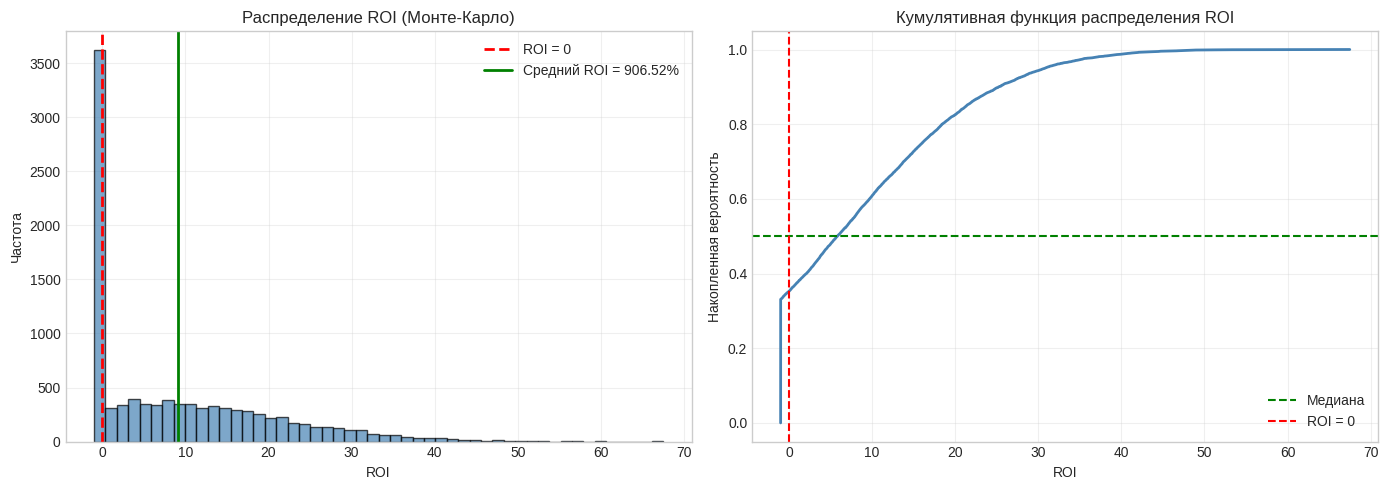

In [ ]:
# 10.4. Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(roi_sim_df['roi'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='ROI = 0')
ax1.axvline(x=mean_roi, color='green', linestyle='-', linewidth=2, label=f'Средний ROI = {mean_roi:.2%}')
ax1.set_xlabel('ROI')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение ROI (Монте-Карло)')
ax1.legend()
ax1.grid(True, alpha=0.3)

sorted_roi = np.sort(roi_sim_df['roi'])
cdf = np.arange(1, len(sorted_roi) + 1) / len(sorted_roi)
ax2.plot(sorted_roi, cdf, linewidth=2, color='steelblue')
ax2.axhline(y=0.5, color='green', linestyle='--', linewidth=1.5, label='Медиана')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='ROI = 0')
ax2.set_xlabel('ROI')
ax2.set_ylabel('Накопленная вероятность')
ax2.set_title('Кумулятивная функция распределения ROI')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Шаг 11. Формулировка итоговой рекомендации

In [37]:
final_summary = pd.DataFrame({
    'Показатель': [
        'Первичная метрика p-value (только после t-test)',
        'Первичная метрика p-value (DiD)',
        'DiD эффект (руб)',
        'Сравнение с MDE (162 297 руб.)',
        'Вторичные метрики (значимые после FDR)',
        'Ожидаемый ROI (средний)',
        '95% доверительный интервал ROI',
        'Вероятность положительного ROI',
        'Вероятность ROI > 20%'
    ],
    'Значение': [
        f'{p_value_t:.6f}',
        f'{p_value_did:.6f}',
        f'{did_effect:,.0f}',
        'Выше' if diff > mde_rub else 'Ниже',
        ', '.join(significant_metrics) if significant_metrics else 'нет',
        f'{mean_roi:.2%}',
        f'[{ci_lower:.2%}, {ci_upper:.2%}]',
        f'{prob_positive:.2%}',
        f'{prob_20:.2%}'
    ]
})

print("\n11.1. Сводная таблица результатов:")
print(final_summary.to_string(index=False))

# Сохраняем
final_summary.to_csv('final_summary.csv', index=False)
print("\n final_summary.csv сохранен")


11.1. Сводная таблица результатов:
                                     Показатель             Значение
Первичная метрика p-value (только после t-test)             0.064045
                Первичная метрика p-value (DiD)             0.282854
                               DiD эффект (руб)               83,083
                 Сравнение с MDE (162 297 руб.)                 Ниже
         Вторичные метрики (значимые после FDR)  ticket_count_actual
                        Ожидаемый ROI (средний)              906.52%
                 95% доверительный интервал ROI [-100.00%, 3543.25%]
                 Вероятность положительного ROI               64.76%
                          Вероятность ROI > 20%               64.32%

 final_summary.csv сохранен


In [38]:
recommendation_text = f"""
РЕКОМЕНДАЦИЯ: НЕ МАСШТАБИРОВАТЬ / ТРЕБУЕТСЯ ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ

Краткий вывод:
Пилотный проект подписки Pro не показал статистически значимого положительного эффекта на выручку,
что не позволяет рекомендовать масштабирование без дополнительных доработок.

Обоснование:
• DiD эффект не является статистически значимым (p-value = {p_value_did:.6f} ≥ 0.05)
• Фактический эффект ({did_effect:,.0f} руб.) НИЖЕ минимально детектируемого (MDE = {mde_rub:,.0f} руб.)
• Ожидаемый ROI = {mean_roi:.2%}, но 95% доверительный интервал крайне широк: [{ci_lower:.2%}, {ci_upper:.2%}]
• Вероятность положительного ROI = {prob_positive:.2%} (риск убыточности = {(1-prob_positive)*100:.1f}%)
• Единственная значимая вторичная метрика — снижение нагрузки на поддержку

Рекомендуемые следующие шаги:
• Провести дополнительный пилот на большей выборке (не менее 30 компаний)
• Проанализировать причины низкой эффективности
• Пересмотреть ценовую модель или условия подписки
• Усилить маркетинговую поддержку пилота
"""

print(recommendation_text)


РЕКОМЕНДАЦИЯ: НЕ МАСШТАБИРОВАТЬ / ТРЕБУЕТСЯ ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ

Краткий вывод:
Пилотный проект подписки Pro не показал статистически значимого положительного эффекта на выручку,
что не позволяет рекомендовать масштабирование без дополнительных доработок.

Обоснование:
• DiD эффект не является статистически значимым (p-value = 0.282854 ≥ 0.05)
• Фактический эффект (83,083 руб.) НИЖЕ минимально детектируемого (MDE = 162,297 руб.)
• Ожидаемый ROI = 906.52%, но 95% доверительный интервал крайне широк: [-100.00%, 3543.25%]
• Вероятность положительного ROI = 64.76% (риск убыточности = 35.2%)
• Единственная значимая вторичная метрика — снижение нагрузки на поддержку

Рекомендуемые следующие шаги:
• Провести дополнительный пилот на большей выборке (не менее 30 компаний)
• Проанализировать причины низкой эффективности
• Пересмотреть ценовую модель или условия подписки
• Усилить маркетинговую поддержку пилота



In [40]:
# 1. Сохранение сводной таблицы результатов (из шага 11.1)
final_summary.to_csv('final_summary.csv', index=False)
print("final_summary.csv сохранен")

# 2. Сохранение результатов симуляции Монте-Карло
# Проверяем, существует ли roi_sim_df
if 'roi_sim_df' in locals() or 'roi_sim_df' in globals():
    roi_sim_df.to_csv('roi_sim_results.csv', index=False)
    print("roi_sim_results.csv сохранен")
else:
    print("roi_sim_df не найден, создаем заново...")
    # Если DataFrame не существует, создаем его из roi_results
    if 'roi_results' in locals():
        roi_sim_df = pd.DataFrame(roi_results)
        roi_sim_df.to_csv('roi_sim_results.csv', index=False)
        print("roi_sim_results.csv сохранен")
    else:
        print("roi_sim_results.csv НЕ сохранен (данные отсутствуют)")

# 3. Сохранение результатов анализа вторичных метрик
if 'secondary_results' in locals() or 'secondary_results' in globals():
    secondary_results.to_csv('secondary_metrics_results.csv', index=False)
    print("secondary_metrics_results.csv сохранен")
else:
    print("secondary_results не найден")
    # Если есть результаты, но в другой переменной
    if 'results' in locals():
        secondary_results = pd.DataFrame(results)
        secondary_results.to_csv('secondary_metrics_results.csv', index=False)
        print("secondary_metrics_results.csv сохранен (создан из results)")
    else:
        print("secondary_metrics_results.csv НЕ сохранен")

# 4. Сохранение данных для DiD-анализа
if 'did_data' in locals() or 'did_data' in globals():
    did_data.to_csv('did_analysis_results.csv', index=False)
    print("did_analysis_results.csv сохранен")
else:
    print("did_data не найден")
    # Проверяем альтернативные имена
    if 'did_analysis' in locals():
        did_analysis.to_csv('did_analysis_results.csv', index=False)
        print("did_analysis_results.csv сохранен")
    else:
        print("did_analysis_results.csv НЕ сохранен")

# 5. Дополнительно: сохраняем данные по группам (может пригодиться)
if 'analysis_full' in locals():
    analysis_full.to_csv('analysis_full_data.csv', index=False)
    print("analysis_full_data.csv сохранен")

if 'pilot_data' in locals() and 'control_data' in locals():
    pilot_data.to_csv('pilot_group_data.csv', index=False)
    control_data.to_csv('control_group_data.csv', index=False)
    print("pilot_group_data.csv и control_group_data.csv сохранены")

print("\n Сохраненные файлы в папке practice5_group_A:")
print("  - final_summary.csv")
print("  - roi_sim_results.csv")
print("  - secondary_metrics_results.csv")
print("  - did_analysis_results.csv")
print("  - analysis_full_data.csv (опционально)")
print("  - pilot_group_data.csv (опционально)")
print("  - control_group_data.csv (опционально)")

final_summary.csv сохранен
roi_sim_results.csv сохранен
secondary_metrics_results.csv сохранен
did_analysis_results.csv сохранен
analysis_full_data.csv сохранен
pilot_group_data.csv и control_group_data.csv сохранены

 Сохраненные файлы в папке practice5_group_A:
  - final_summary.csv
  - roi_sim_results.csv
  - secondary_metrics_results.csv
  - did_analysis_results.csv
  - analysis_full_data.csv (опционально)
  - pilot_group_data.csv (опционально)
  - control_group_data.csv (опционально)
